# Exploratory Data Analysis (EDA)

Loads all CSV files from a user-defined folder and performs a structured EDA.

| Section | Content |
|---|---|
| **1. Per-File** | Descriptive stats · Kurtosis & Skewness · Histograms · Correlation matrix |
| **2. Aggregate** | Global stats on concatenated data · Cross-file summary · Aggregate histograms · Correlation matrices |

> Per-file **plots** are capped at `MAX_FILES_DISPLAY` to keep the output manageable.

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

In [52]:
# ── USER INPUT ────────────────────────────────────────────────────────────────
load_from_dir = "../data/filtered_windows/pre_2001"  # <-- set your folder here

# Max files for which per-file PLOTS are rendered (set None to plot all files)
MAX_FILES_DISPLAY = 5
# ─────────────────────────────────────────────────────────────────────────────

---
## 0. Data Loading

In [ ]:
csv_paths = sorted(Path(load_from_dir).glob("*.csv"))
assert len(csv_paths) > 0, f"No CSV files found in '{load_from_dir}'"

dataframes = {p.stem: pd.read_csv(p) for p in csv_paths}
print(f"Loaded {len(dataframes)} file(s) from '{load_from_dir}'")

# Schema check
schemas = {name: tuple(df.columns.tolist()) for name, df in dataframes.items()}
unique_schemas = set(schemas.values())
if len(unique_schemas) == 1:
    cols = list(unique_schemas)[0]
    print(f"Shared schema ({len(cols)} columns): {cols}")
else:
    print(f"WARNING: {len(unique_schemas)} different schemas detected.")
    for schema in unique_schemas:
        count = sum(1 for v in schemas.values() if v == schema)
        print(f"  {schema}  →  {count} file(s)")

---
## 1. Per-File Statistics

For each CSV: descriptive statistics (mean, median, std, min, max), kurtosis, skewness, histograms, and correlation matrix.

### 1.1 Descriptive Statistics per File

In [ ]:
summary_rows = []

for name, df in dataframes.items():
    num_df = df.select_dtypes(include='number')
    if num_df.empty:
        continue

    desc   = num_df.describe()
    median = num_df.median().rename('median')
    kurt   = num_df.kurtosis().rename('kurtosis')
    skew   = num_df.skew().rename('skewness')

    extended = pd.concat([desc, median.to_frame().T, kurt.to_frame().T, skew.to_frame().T])
    row_order = ['count', 'mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max', 'kurtosis', 'skewness']
    extended  = extended.reindex([r for r in row_order if r in extended.index])

    print(f"\n{'─'*60}\n  {name}\n{'─'*60}")
    display(extended)

    # Collect for cross-file summary
    for col in num_df.columns:
        summary_rows.append({
            'file':     name,
            'column':   col,
            'mean':     num_df[col].mean(),
            'median':   num_df[col].median(),
            'std':      num_df[col].std(),
            'min':      num_df[col].min(),
            'max':      num_df[col].max(),
            'kurtosis': num_df[col].kurtosis(),
            'skewness': num_df[col].skew(),
        })

per_file_summary = pd.DataFrame(summary_rows)


────────────────────────────────────────────────────────────
  raw_AAPL_1980-12-12_2026-04-10_w0000014_s5600
────────────────────────────────────────────────────────────


,log_adj_close
count,2048.0000
mean,0.0019
median,0.0019
std,0.0249
min,-0.1975
25%,-0.0112
50%,0.0019
75%,0.0153
max,0.1302
kurtosis,4.2362



────────────────────────────────────────────────────────────
  raw_AAPL_1980-12-12_2026-04-10_w0000015_s6000
────────────────────────────────────────────────────────────


,log_adj_close
count,2048.0000
mean,0.0017
median,0.0017
std,0.0238
min,-0.1975
25%,-0.0105
50%,0.0017
75%,0.0142
max,0.1302
kurtosis,4.8578



────────────────────────────────────────────────────────────
  raw_AAPL_1980-12-12_2026-04-10_w0000016_s6400
────────────────────────────────────────────────────────────


...

,log_adj_close
count,2048.0000
mean,0.0002
median,0.0001
std,0.0178
min,-0.1304
25%,-0.0079
50%,0.0001
75%,0.0083
max,0.1194
kurtosis,7.4466



────────────────────────────────────────────────────────────
  raw_XOM_1962-01-02_2026-04-10_w0005566_s13600
────────────────────────────────────────────────────────────


,log_adj_close
count,2048.0000
mean,0.0003
median,0.0004
std,0.0183
min,-0.1304
25%,-0.0084
50%,0.0004
75%,0.0091
max,0.1194
kurtosis,6.4845



────────────────────────────────────────────────────────────
  raw_XOM_1962-01-02_2026-04-10_w0005567_s14000
────────────────────────────────────────────────────────────


,log_adj_close
count,2048.0000
mean,0.0004
median,0.0006
std,0.0188
min,-0.1304
25%,-0.0089
50%,0.0006
75%,0.0099
max,0.1194
kurtosis,5.8486


### 1.2 Per-File Histograms
> Limited to the first `MAX_FILES_DISPLAY` files.

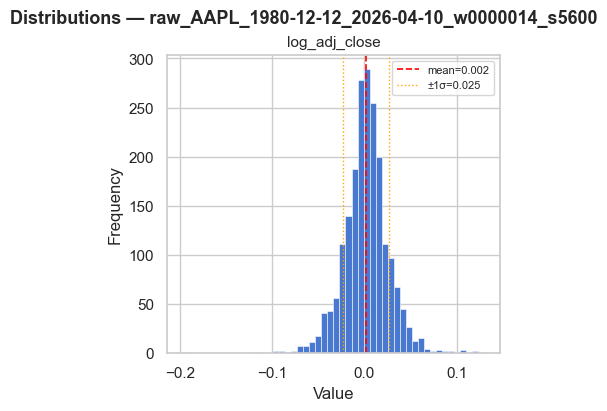

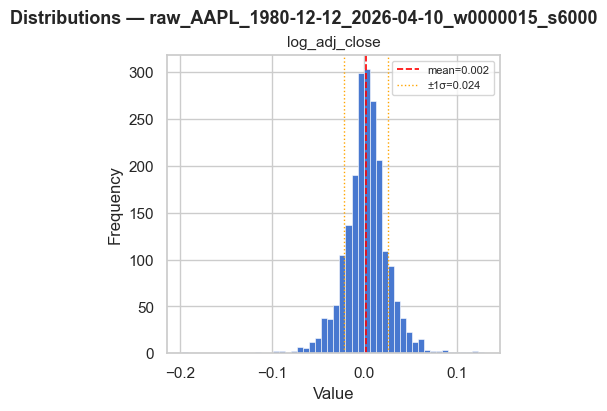

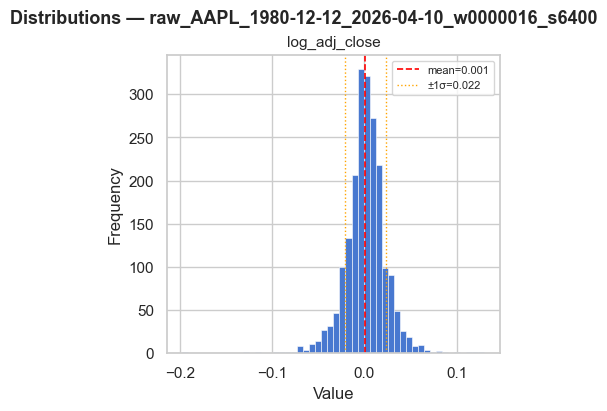

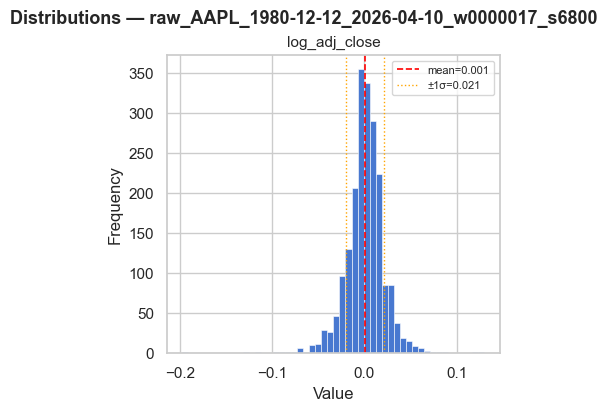

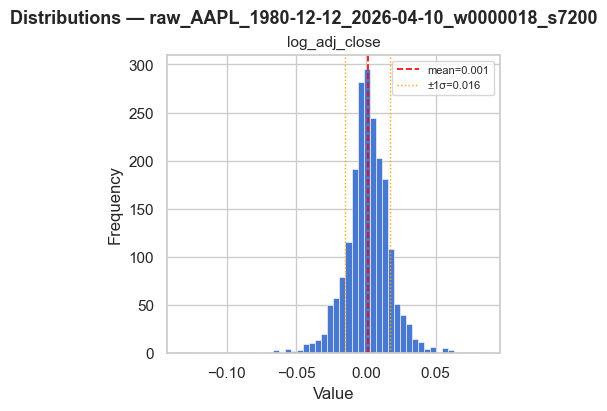

In [ ]:
plot_items = list(dataframes.items())
if MAX_FILES_DISPLAY is not None:
    plot_items = plot_items[:MAX_FILES_DISPLAY]

for name, df in plot_items:
    num_df = df.select_dtypes(include='number')
    if num_df.empty:
        continue

    n_cols = len(num_df.columns)
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4), constrained_layout=True)
    if n_cols == 1:
        axes = [axes]

    for ax, col in zip(axes, num_df.columns):
        data = num_df[col].dropna()
        ax.hist(data, bins=50, edgecolor='white', linewidth=0.4)
        mu, sigma = data.mean(), data.std()
        ax.axvline(mu, color='red',    linestyle='--', linewidth=1.2, label=f'mean={mu:.3f}')
        ax.axvline(mu + sigma, color='orange', linestyle=':',  linewidth=1.0)
        ax.axvline(mu - sigma, color='orange', linestyle=':',  linewidth=1.0, label=f'\u00b11\u03c3={sigma:.3f}')
        ax.set_title(col, fontsize=11)
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')
        ax.legend(fontsize=8)

    fig.suptitle(f"Distributions \u2014 {name}", fontsize=13, fontweight='bold')
    plt.show()

### 1.3 Per-File Correlation Matrix
> Limited to the first `MAX_FILES_DISPLAY` files.

In [ ]:
for name, df in plot_items:
    num_df = df.select_dtypes(include='number')
    if num_df.shape[1] < 2:
        print(f"{name}: only one numeric column, correlation skipped.")
        continue

    corr = num_df.corr()
    size = max(4, len(corr) * 0.9 + 1)
    fig, ax = plt.subplots(figsize=(size, size * 0.8))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                linewidths=0.5, ax=ax, vmin=-1, vmax=1)
    ax.set_title(f"Correlation Matrix \u2014 {name}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

raw_AAPL_1980-12-12_2026-04-10_w0000014_s5600: only one numeric column, correlation skipped.
raw_AAPL_1980-12-12_2026-04-10_w0000015_s6000: only one numeric column, correlation skipped.
raw_AAPL_1980-12-12_2026-04-10_w0000016_s6400: only one numeric column, correlation skipped.
raw_AAPL_1980-12-12_2026-04-10_w0000017_s6800: only one numeric column, correlation skipped.
raw_AAPL_1980-12-12_2026-04-10_w0000018_s7200: only one numeric column, correlation skipped.


---
## 2. Aggregate Statistics

Statistics computed over **all files combined** (rows from every CSV concatenated).
The cross-file summary shows per-column statistics averaged across files, giving a
sense of how consistent individual files are relative to the global distribution.

### 2.1 Aggregate Descriptive Statistics

In [ ]:
# Build combined dataset on the intersection of numeric columns
common_cols = sorted(
    set.intersection(*[set(df.select_dtypes(include='number').columns)
                       for df in dataframes.values()])
)
combined_df = pd.concat(
    [df[common_cols] for df in dataframes.values()],
    ignore_index=True
)
print(f"Combined dataset: {len(combined_df):,} rows x {len(common_cols)} columns")
print(f"Columns: {common_cols}\n")

# Extended describe
desc   = combined_df.describe()
median = combined_df.median().rename('median')
kurt   = combined_df.kurtosis().rename('kurtosis')
skew   = combined_df.skew().rename('skewness')

agg_stats = pd.concat([desc, median.to_frame().T, kurt.to_frame().T, skew.to_frame().T])
row_order  = ['count', 'mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max', 'kurtosis', 'skewness']
agg_stats  = agg_stats.reindex([r for r in row_order if r in agg_stats.index])

print("Aggregate Descriptive Statistics (all files combined):")
display(agg_stats)

Combined dataset: 4,325,376 rows x 1 columns
Columns: ['log_adj_close']

Aggregate Descriptive Statistics (all files combined):


,log_adj_close
count,4325376.0000
mean,0.0004
median,0.0006
std,0.0200
min,-0.9363
25%,-0.0077
50%,0.0006
75%,0.0089
max,0.5573
kurtosis,41.6921


### 2.2 Cross-File Summary

Mean and standard deviation of each per-file statistic, grouped by column.
High std values indicate heterogeneity across files.

In [ ]:
cross_file = (
    per_file_summary
    .groupby('column')[['mean', 'median', 'std', 'min', 'max', 'kurtosis', 'skewness']]
    .agg(['mean', 'std'])
)
cross_file.columns = [f"{stat}_{agg}" for stat, agg in cross_file.columns]
display(cross_file)

,mean_mean,mean_std,median_mean,median_std,std_mean,std_std,min_mean,min_std,max_mean,max_std,kurtosis_mean,kurtosis_std,skewness_mean,skewness_std
column,,,,,,,,,,,,,,
log_adj_close,0.0004,0.0003,0.0006,0.0004,0.0189,0.0064,-0.1608,0.1007,0.1449,0.0692,13.2290,23.5503,-0.3068,0.9688


### 2.3 Aggregate Histograms

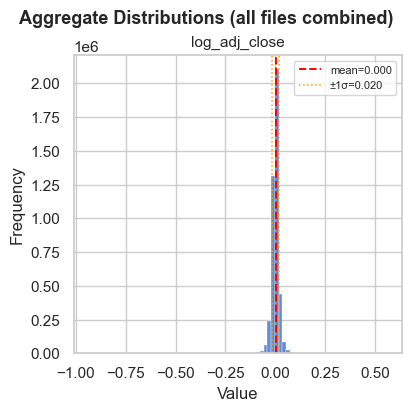

In [ ]:
n_cols = len(common_cols)
fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4), constrained_layout=True)
if n_cols == 1:
    axes = [axes]

for ax, col in zip(axes, common_cols):
    data = combined_df[col].dropna()
    ax.hist(data, bins=80, edgecolor='white', linewidth=0.3, alpha=0.85)
    mu, sigma = data.mean(), data.std()
    ax.axvline(mu, color='red',    linestyle='--', linewidth=1.4, label=f'mean={mu:.3f}')
    ax.axvline(mu + sigma, color='orange', linestyle=':',  linewidth=1.1)
    ax.axvline(mu - sigma, color='orange', linestyle=':',  linewidth=1.1, label=f'\u00b11\u03c3={sigma:.3f}')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

fig.suptitle("Aggregate Distributions (all files combined)", fontsize=13, fontweight='bold')
plt.show()

### 2.4 Aggregate Correlation Matrices

Two complementary views:
- **Left** — correlation computed on the full concatenated dataset
- **Right** — element-wise mean of per-file correlation matrices (preserves within-file structure)

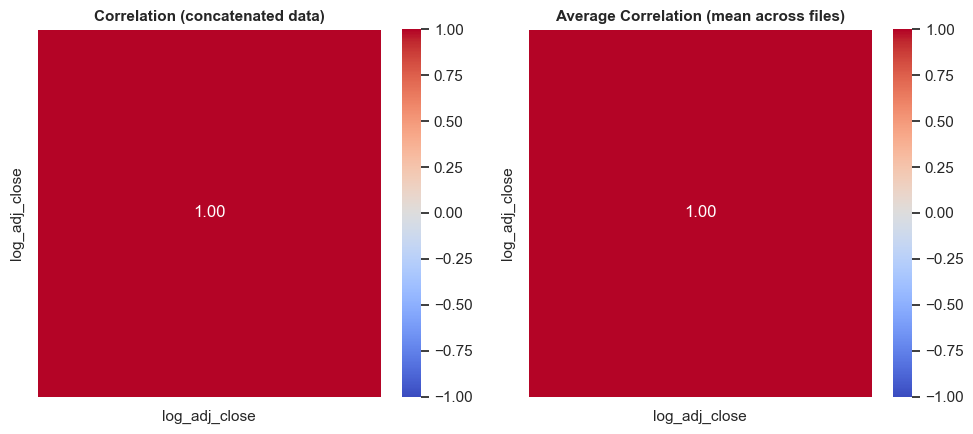

In [ ]:
# Per-file correlation matrices stacked
corr_stack = np.array([
    df[common_cols].corr().values
    for df in dataframes.values()
    if df[common_cols].shape[0] > 1
])
avg_corr = pd.DataFrame(corr_stack.mean(axis=0), index=common_cols, columns=common_cols)

size = max(5, len(common_cols) * 1.2 + 1)
fig, axes = plt.subplots(1, 2, figsize=(size * 2, size * 0.9))

# Left: concatenated
corr_combined = combined_df.corr()
sns.heatmap(corr_combined, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title("Correlation (concatenated data)", fontsize=11, fontweight='bold')

# Right: average across files
sns.heatmap(avg_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title("Average Correlation (mean across files)", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()